Total samples: 200
Training samples:   140
Validation samples: 30
Test samples:       30
omega mean: 0.1262, std: 0.3801
Original training samples:  140
Augmented training samples: 420


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Phase 1: Training top layers only ---
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - loss: 1.4367 - val_loss: 1.7846
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - loss: 0.9223 - val_loss: 1.6750
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.8809 - val_loss: 1.8549
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.9011 - val_loss: 2.1803
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.8463 - val_loss: 1.8428
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.7763 - val_loss: 2.0243
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.7314 - val_loss: 1.6695
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.7576 - val_loss: 1.6295
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 0.6636 - val_loss: 1.5209
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.7340 - val_loss: 1.6027
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.6956 - val_loss: 1.6800
Epoch 12/50
53/

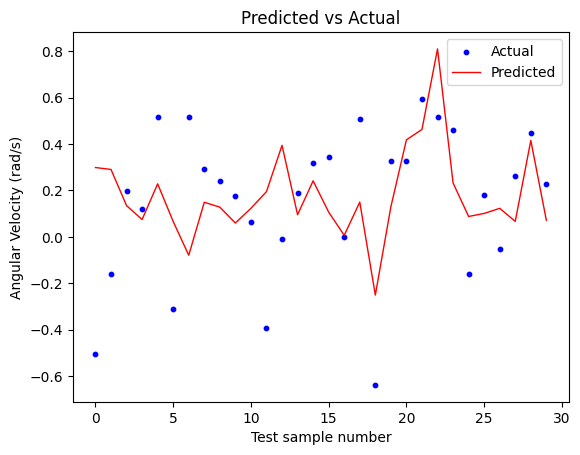

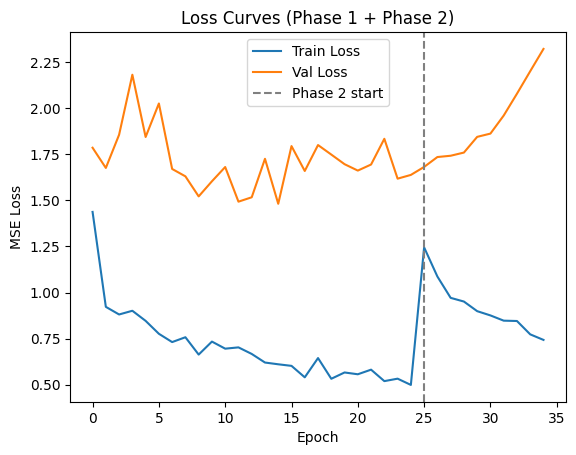

INFO:tensorflow:Assets written to: ambulance_model_savedmodel\assets


INFO:tensorflow:Assets written to: ambulance_model_savedmodel\assets


Saved artifact at 'ambulance_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_521')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2593233483920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259656336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259666896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259658064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259654992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259665168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259653456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259667088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259661136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259665936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2593259664976: Tenso

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 

#Path to images 
image_dir = Path("C:/Users/laure/Downloads/ambulance pics")
#File with the angular velocity corresponding to each image
csv_path  = Path("C:/Users/laure/Downloads/output_Results 2.csv")
 
data = pd.read_csv(csv_path)
print("Total samples:", len(data))
 
#Function to load the images 
def load_image(img_path):
    img = cv2.imread(str(img_path))
    #Makes sure all images are same size
    img = cv2.resize(img, (224, 224))
    #Normalize images
    img = img / 255.0
    #Gives back processed image
    return img.astype(np.float32)
 
images  = []
ang_vel = []
 
for i in range(len(data)):
    #Get image name from CSV
    img_name = int(data["Image"][i])
    #Get angular velocity for corresponding image
    angular  = data["Angular velocity"][i]
    #Folder path and file name
    img_path = image_dir / ("image" + str(img_name) + ".png")
    #Storing data with corresponding image(CNN input) and label (What the CNN should learn to predict (angular velocity))
    images.append(load_image(img_path))
    ang_vel.append(angular)
 
images  = np.array(images)
angular = np.array(ang_vel)
 
#Reference: https://dzone.com/articles/data-splits-machine-learning-training-validation-test
#Split training (70%)
X_train, X_temp, y_train, y_temp = train_test_split(
    images, angular, test_size=0.3, random_state=42
)
#Split validation (15%) + test(15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
 
print("Training samples:  ", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:      ", len(X_test))
 
 
#Normalize labels
omega_mean = y_train.mean()
omega_std  = y_train.std()
 
y_train_norm = (y_train - omega_mean) / omega_std
y_val_norm   = (y_val   - omega_mean) / omega_std
y_test_norm  = (y_test  - omega_mean) / omega_std
 
print("omega mean: " + str(round(omega_mean, 4)) + ", std: " + str(round(omega_std, 4)))
 
#Data augmentation using brightness and contrast adjustments to improve generalization, increases the dataset size by a factor of 3
brightness_aug = tf.keras.Sequential([layers.RandomBrightness(0.2)])
contrast_aug   = tf.keras.Sequential([layers.RandomContrast(0.2)])
 
#Original
X_train_orig    = X_train.copy()
y_train_orig    = y_train_norm.copy()
 
#Brightness-augmented images
X_train_bright  = np.clip(brightness_aug(X_train, training=True).numpy(), 0, 1)
y_train_bright  = y_train_norm.copy()
 
#Contrast-augmented images
X_train_contrast = np.clip(contrast_aug(X_train, training=True).numpy(), 0, 1)
y_train_contrast = y_train_norm.copy()
 
#All three combined (original, brightness, contrast)
X_train_aug = np.concatenate([X_train_orig, X_train_bright, X_train_contrast], axis=0)
y_train_aug = np.concatenate([y_train_orig, y_train_bright, y_train_contrast], axis=0)
 
#Shuffle to prevent model seeing patterns
idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx]
y_train_aug = y_train_aug[idx]
 
print("Original training samples: ", len(X_train))
print("Augmented training samples:", len(X_train_aug))
 
 #CNN model:
 
#MobileNetV2 pretrained on images (transfer learning)
base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False
 
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1) 
])
 
model.summary()
 
 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
 
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(1e-3))
 
print(" Phase 1: Training top layers only")
history1 = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val_norm),
    batch_size=8,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)
 

base.trainable = True
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(1e-5))
 
print("Phase 2: Fine tuning full model")
history2 = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val_norm),
    batch_size=8,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)
 

#Predictions on unseen test data 
y_pred_norm = model.predict(X_test)
 
#Undo normalziation - back to original
y_pred = y_pred_norm * omega_std + omega_mean
y_test_actual = y_test  
 
mse  = mean_squared_error(y_test_actual, y_pred)
print("MSE:  %.4f" % mse)
print("RMSE: %.4f" % np.sqrt(mse))
 
 
#Predicted vs Actual
x_ax = range(len(y_pred))
plt.figure()
plt.scatter(x_ax, y_test_actual, s=10, color="blue", label="Actual")
plt.plot(x_ax, y_pred, lw=1, color="red", label="Predicted")
plt.xlabel("Test sample number")
plt.ylabel("Angular Velocity (rad/s)")
plt.legend()
plt.title("Predicted vs Actual")
plt.show()
 
combined_train_loss = history1.history['loss'] + history2.history['loss']
combined_val_loss   = history1.history['val_loss'] + history2.history['val_loss']
 
plt.figure()
plt.plot(combined_train_loss, label='Train Loss')
plt.plot(combined_val_loss,   label='Val Loss')
plt.axvline(x=len(history1.history['loss']), color='gray', linestyle='--', label='Phase 2 start')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Loss Curves (Phase 1 + Phase 2)")
plt.show()

 
model.save("ambulance_model.h5")
 
model.export("ambulance_model_savedmodel")
 
np.save("omega_norm_params.npy", np.array([omega_mean, omega_std]))
 
print("Model saved to ambulance_model.h5")
print("Model exported to ambulance_model_savedmodel/")
print("Normalization params saved to omega_norm_params.npy")
print("To reverse normalization: omega = prediction * " + str(round(omega_std, 4)) + " + " + str(round(omega_mean, 4)))